In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    BisectingKMeans
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

from scipy.cluster.hierarchy import linkage, dendrogram

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("StressLevelDataset.csv")

df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [3]:
print("Shape:",df.shape)

df.info()

Shape: (1100, 21)
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
anxiety_level,1100.0,11.063636,6.117558,0.0,6.0,11.0,16.0,21.0
self_esteem,1100.0,17.777273,8.944599,0.0,11.0,19.0,26.0,30.0
mental_health_history,1100.0,0.492727,0.500175,0.0,0.0,0.0,1.0,1.0
depression,1100.0,12.555455,7.727008,0.0,6.0,12.0,19.0,27.0
headache,1100.0,2.508182,1.409356,0.0,1.0,3.0,3.0,5.0
blood_pressure,1100.0,2.181818,0.833575,1.0,1.0,2.0,3.0,3.0
sleep_quality,1100.0,2.660000,1.548383,0.0,1.0,2.5,4.0,5.0
breathing_problem,1100.0,2.753636,1.400713,0.0,2.0,3.0,4.0,5.0
noise_level,1100.0,2.649091,1.328127,0.0,2.0,3.0,3.0,5.0
living_conditions,1100.0,2.518182,1.119208,0.0,2.0,2.0,3.0,5.0


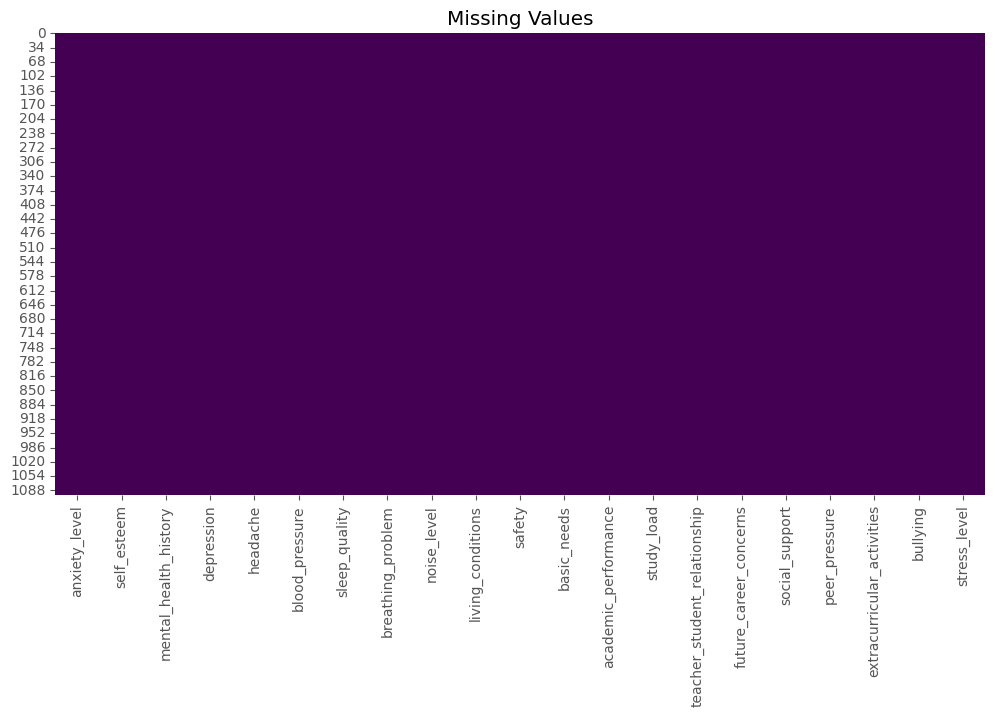

In [5]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values")
plt.show()

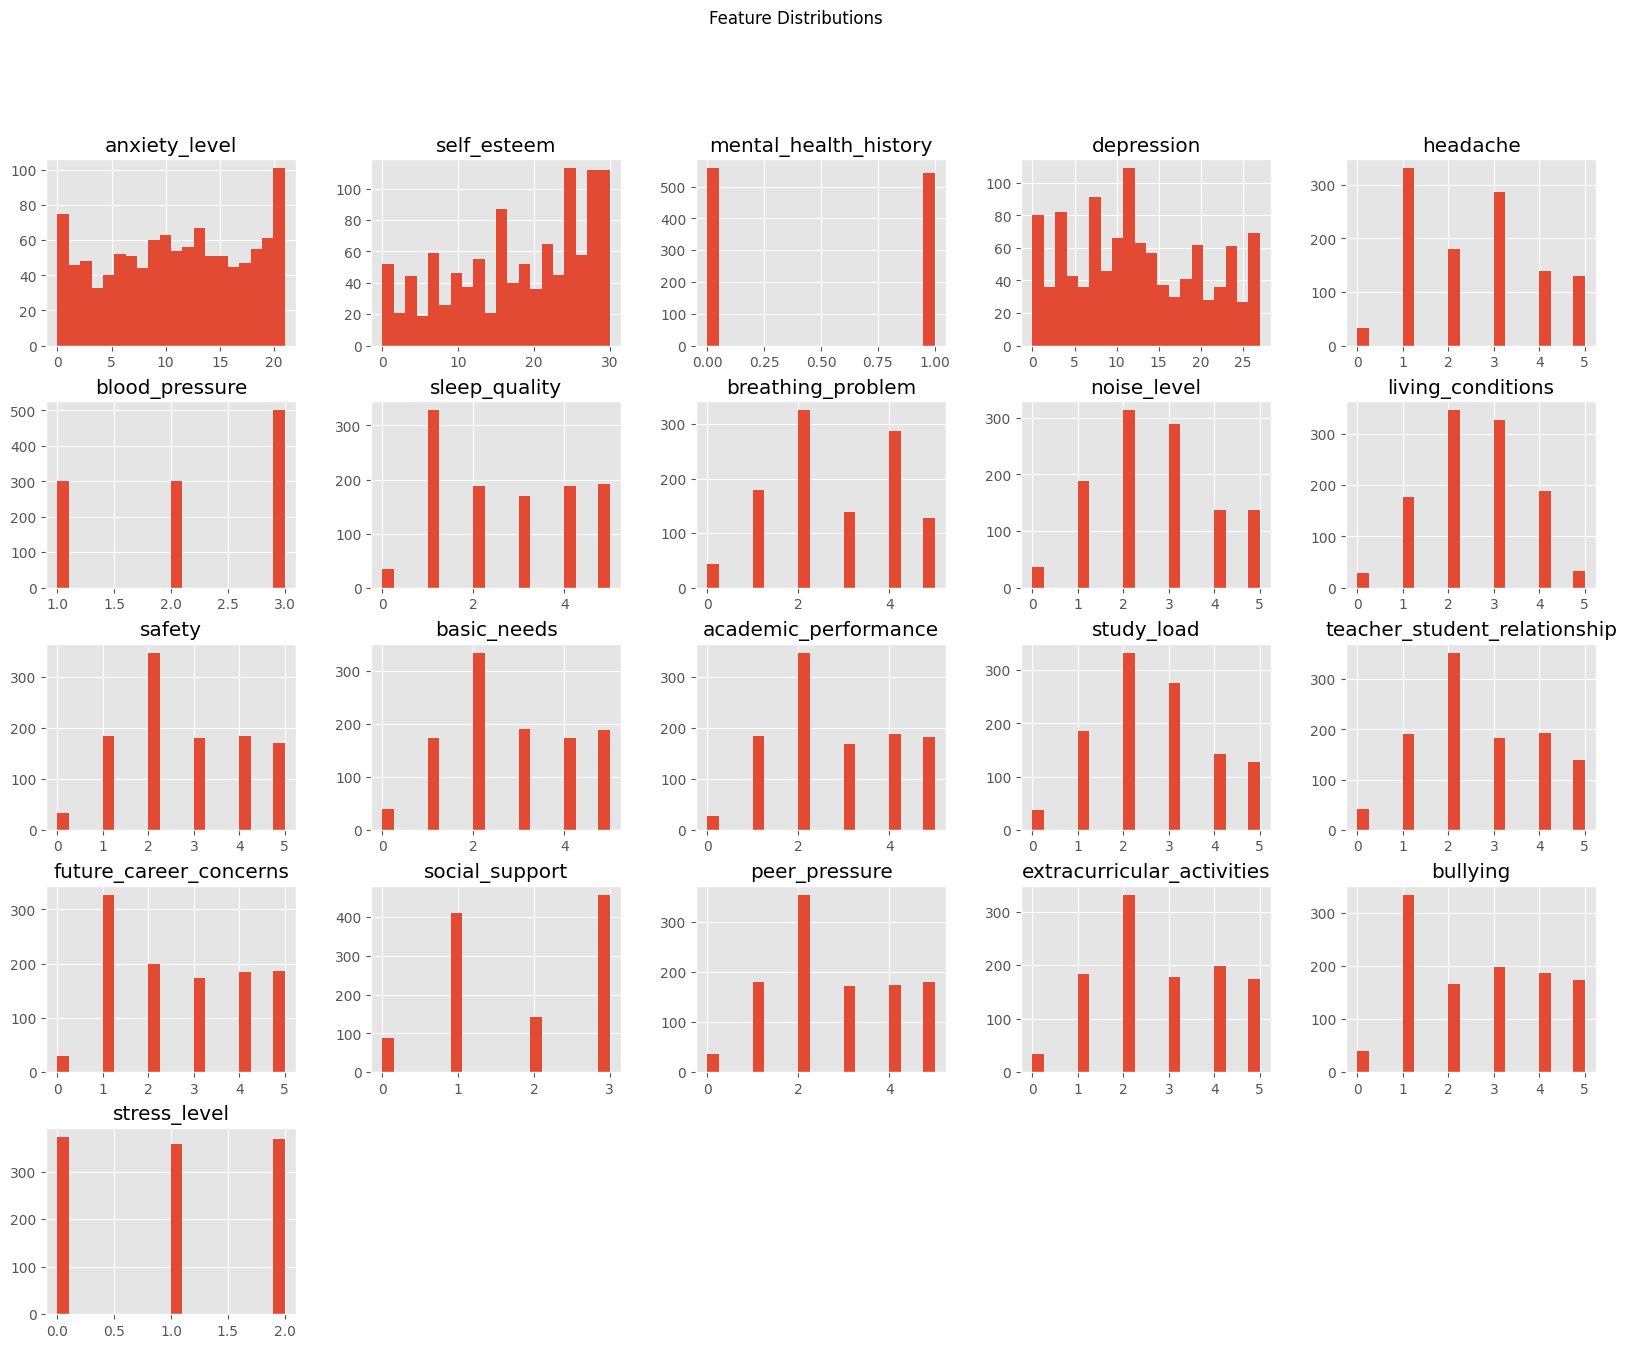

In [6]:
df.hist(
    figsize=(20,15),
    bins=20
)

plt.suptitle("Feature Distributions")

plt.show()

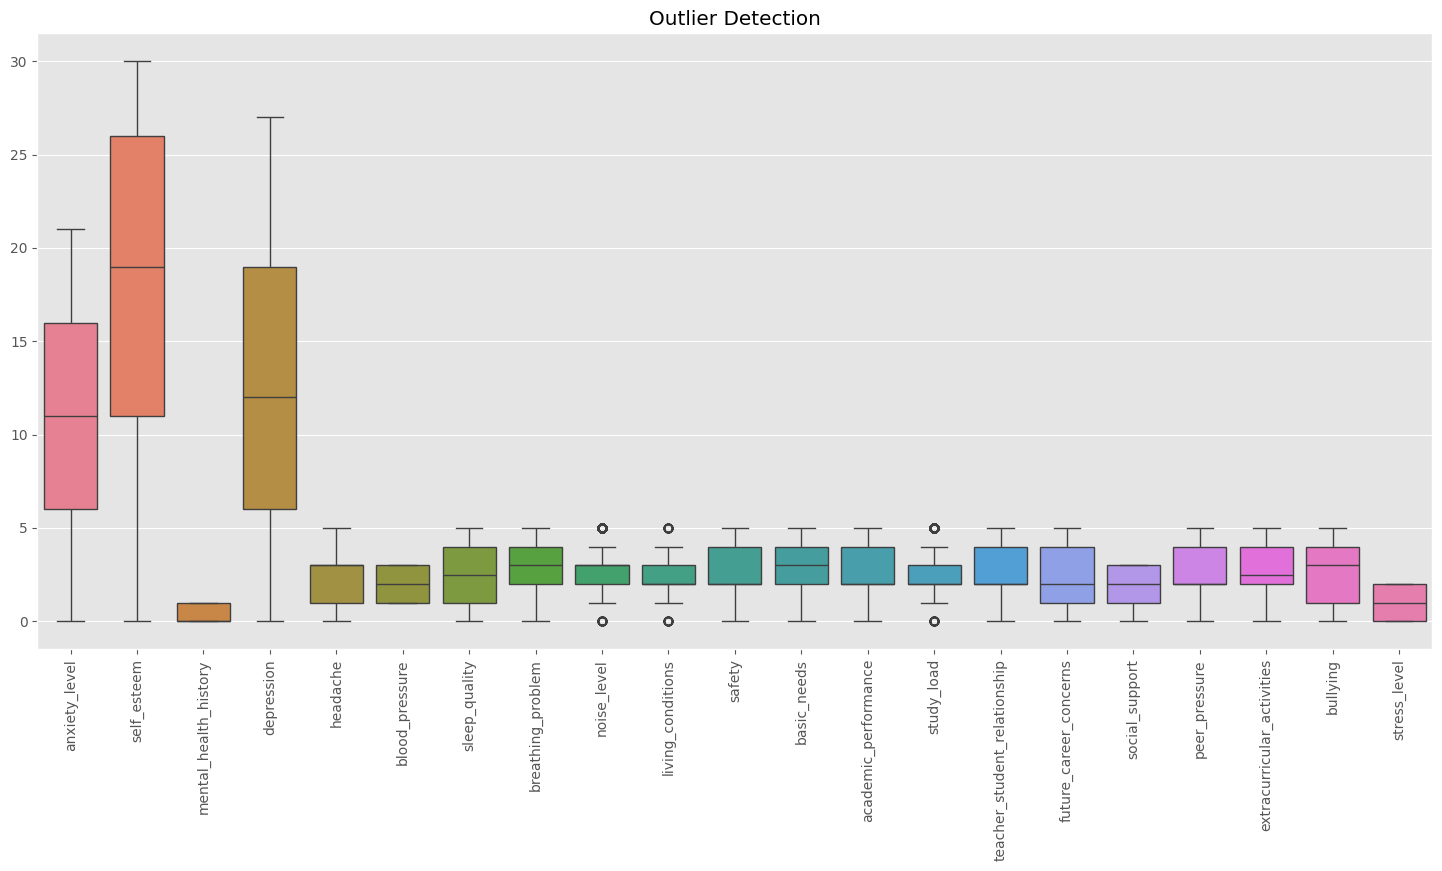

In [7]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Outlier Detection")

plt.show()

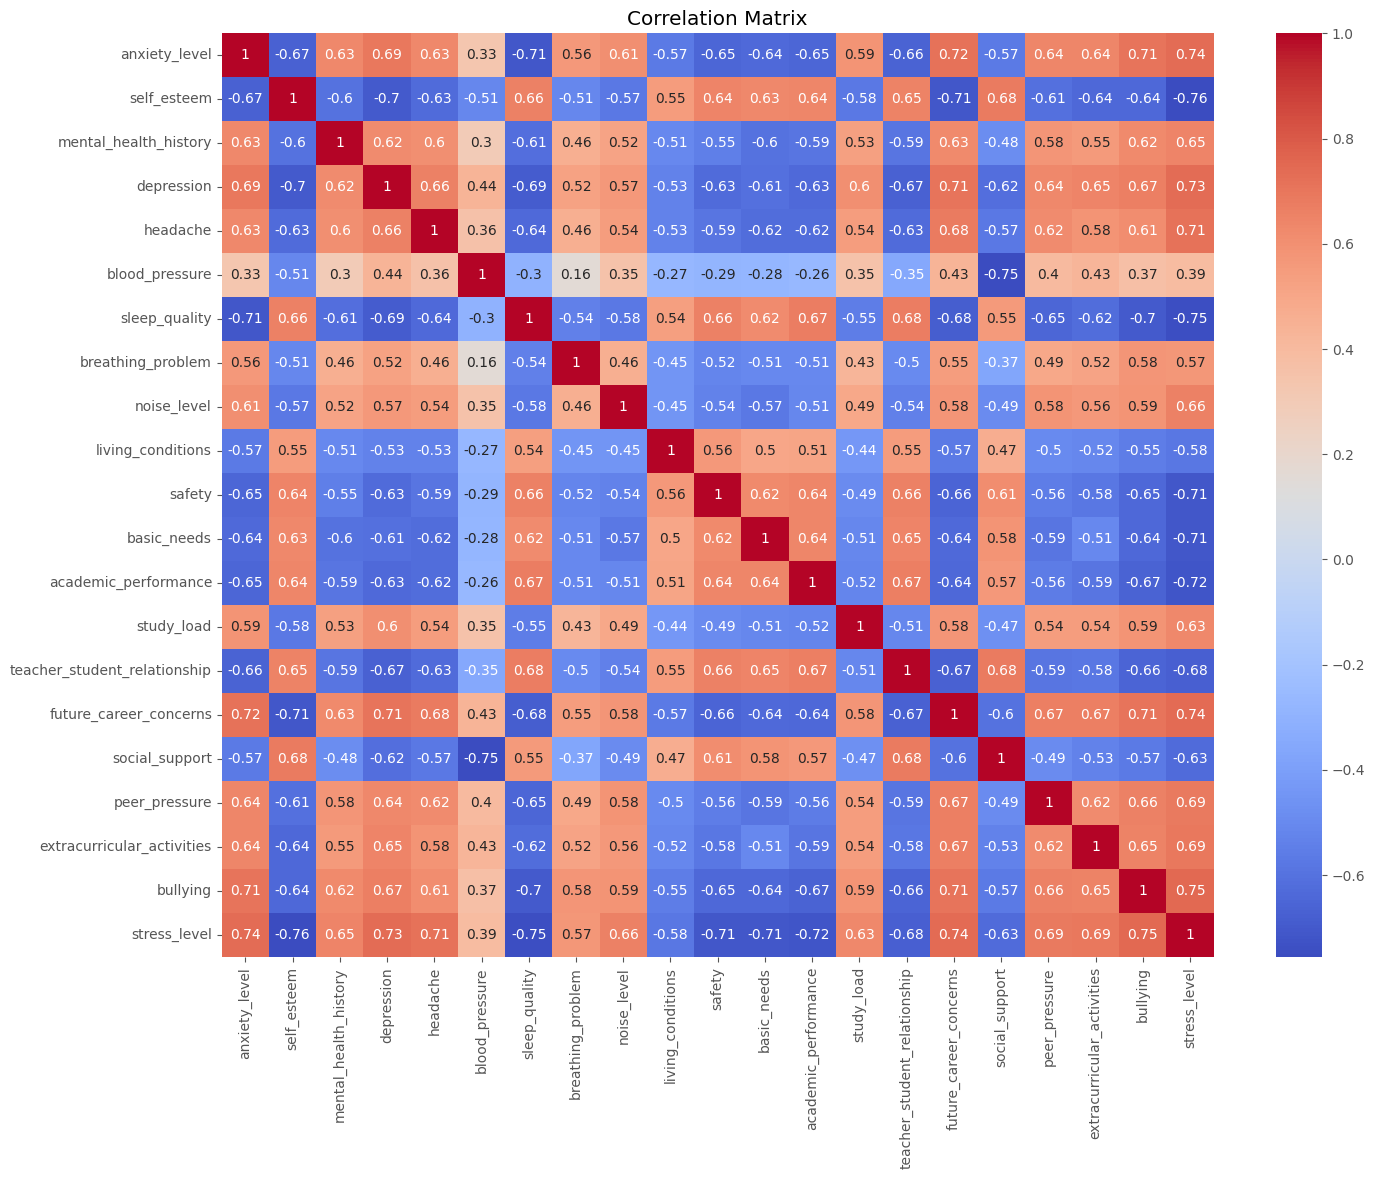

In [8]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [9]:
X = df.drop("stress_level",axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

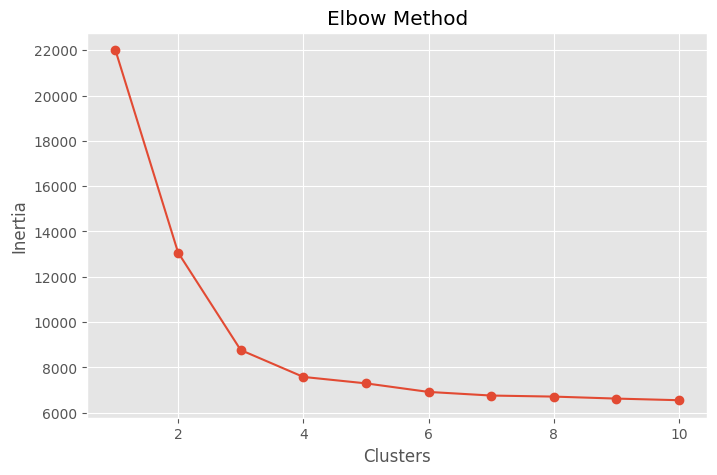

In [10]:
inertia=[]

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("Inertia")

plt.show()

In [11]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

In [12]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

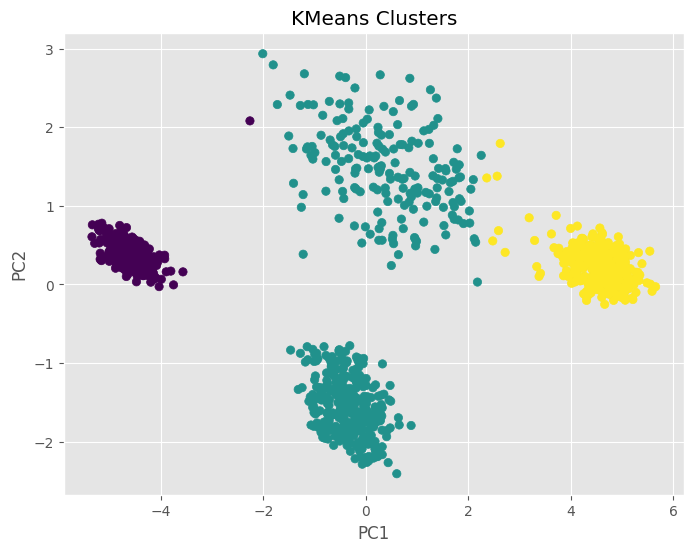

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="viridis"
)

plt.title("KMeans Clusters")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

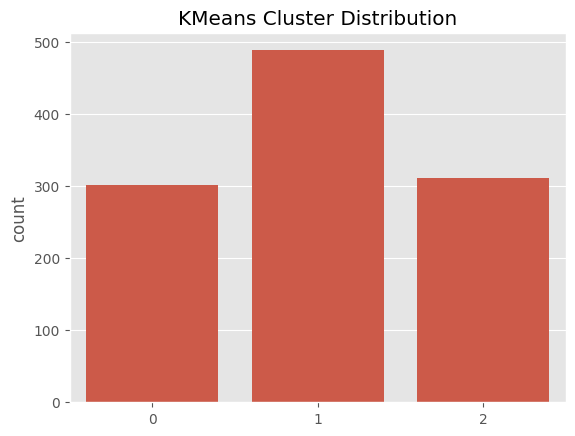

In [14]:
sns.countplot(
    x=kmeans_labels
)

plt.title("KMeans Cluster Distribution")

plt.show()

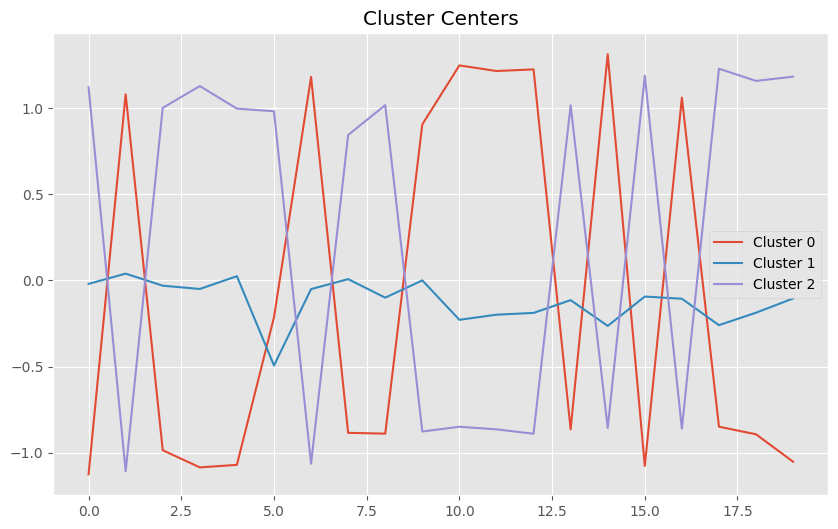

In [15]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10,6))

for i in range(len(centroids)):
    plt.plot(
        centroids[i],
        label=f"Cluster {i}"
    )

plt.legend()

plt.title("Cluster Centers")

plt.show()

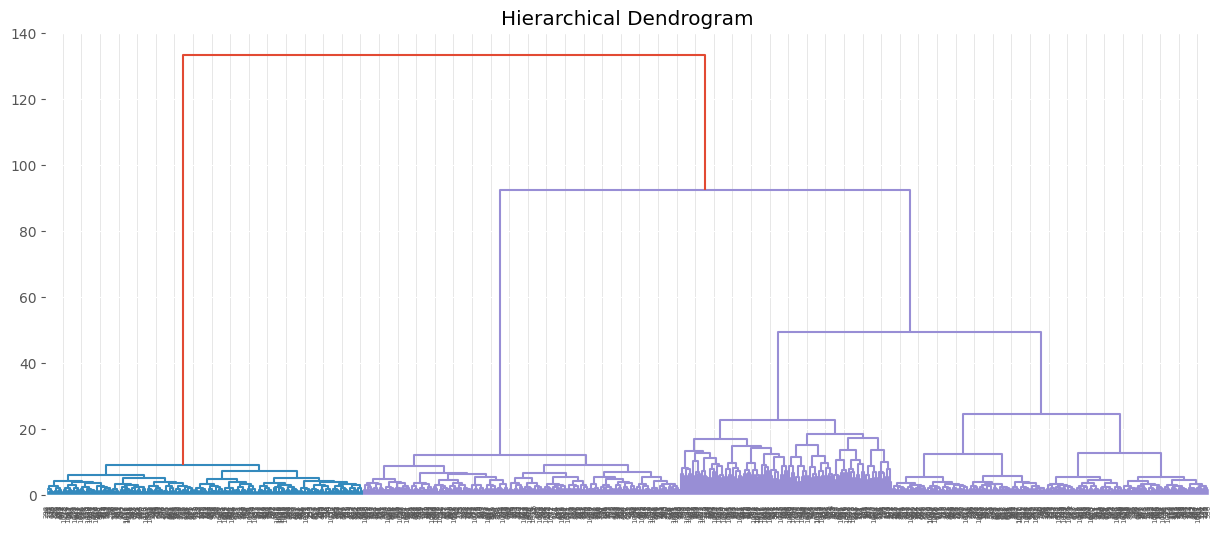

In [16]:
linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(15,6))

dendrogram(linked)

plt.title("Hierarchical Dendrogram")

plt.show()

In [17]:
agg = AgglomerativeClustering(
    n_clusters=3
)

agg_labels = agg.fit_predict(X_scaled)

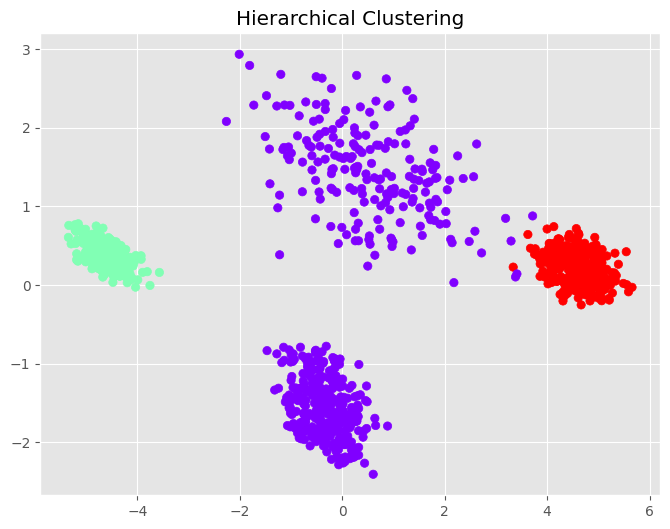

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=agg_labels,
    cmap="rainbow"
)

plt.title("Hierarchical Clustering")

plt.show()

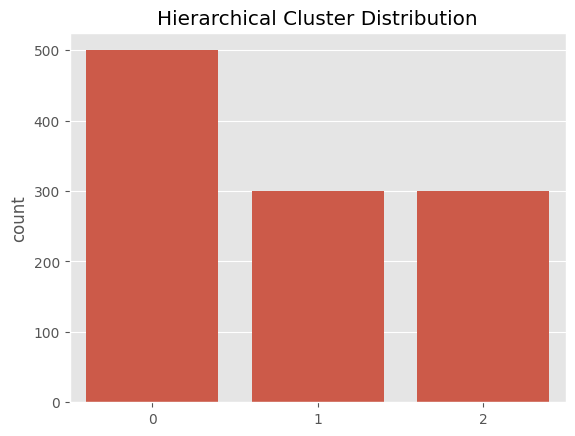

In [19]:
sns.countplot(
    x=agg_labels
)

plt.title("Hierarchical Cluster Distribution")

plt.show()

In [20]:
div = BisectingKMeans(
    n_clusters=3,
    random_state=42
)

div_labels = div.fit_predict(X_scaled)

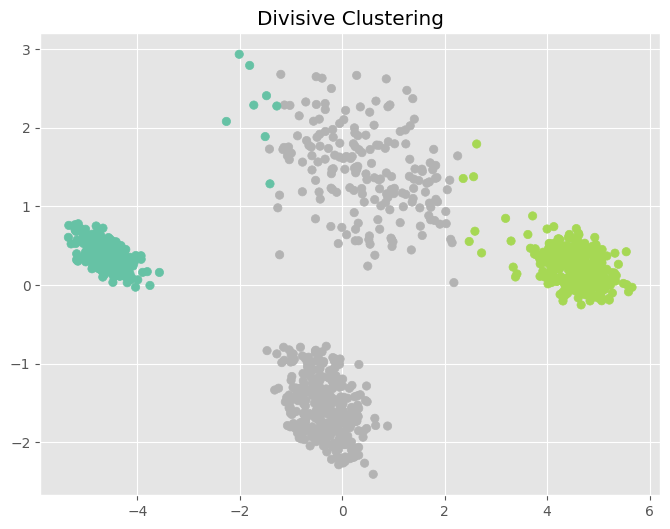

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=div_labels,
    cmap="Set2"
)

plt.title("Divisive Clustering")

plt.show()

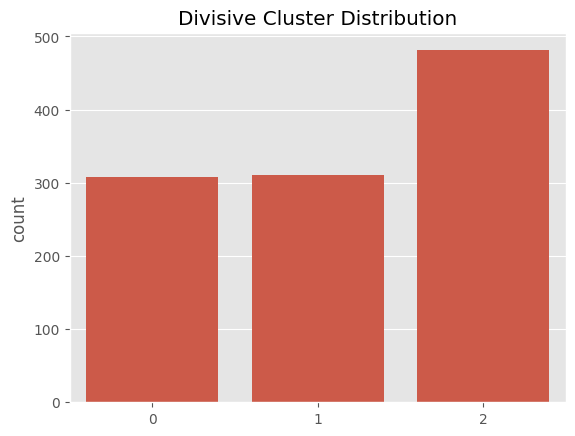

In [22]:
sns.countplot(
    x=div_labels
)

plt.title("Divisive Cluster Distribution")

plt.show()

In [23]:
db = DBSCAN(
    eps=2.5,
    min_samples=5
)

db_labels = db.fit_predict(X_scaled)

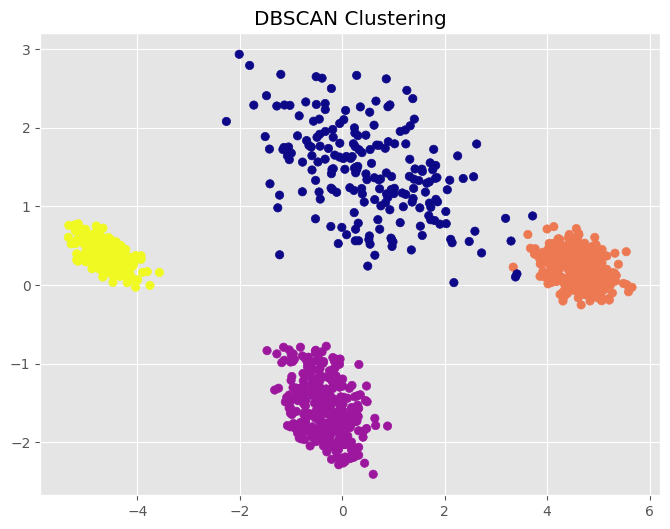

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=db_labels,
    cmap="plasma"
)

plt.title("DBSCAN Clustering")

plt.show()

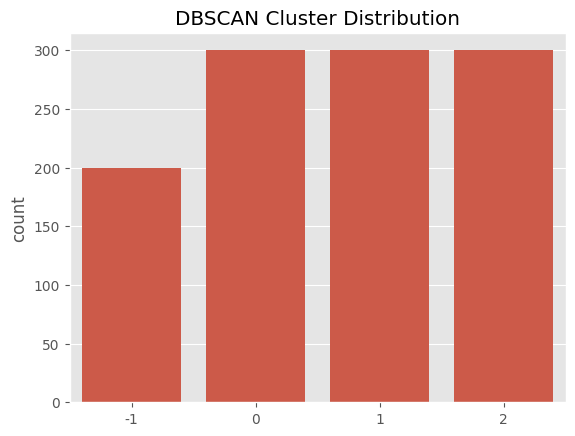

In [25]:
sns.countplot(
    x=db_labels
)

plt.title("DBSCAN Cluster Distribution")

plt.show()

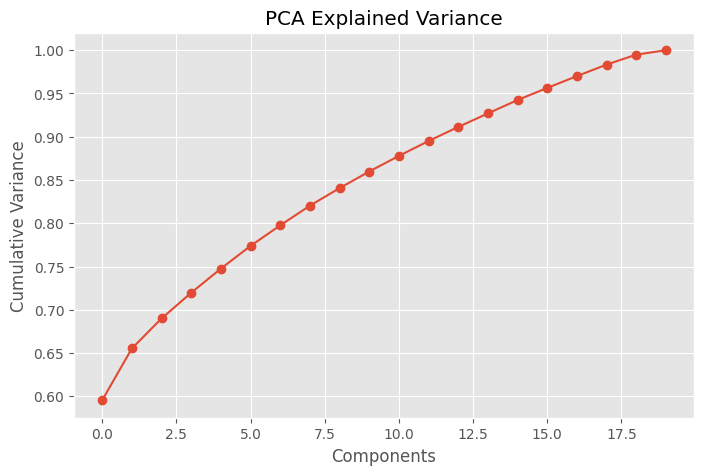

In [26]:
pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(
        pca_full.explained_variance_ratio_
    ),
    marker="o"
)

plt.title("PCA Explained Variance")

plt.xlabel("Components")

plt.ylabel("Cumulative Variance")

plt.show()

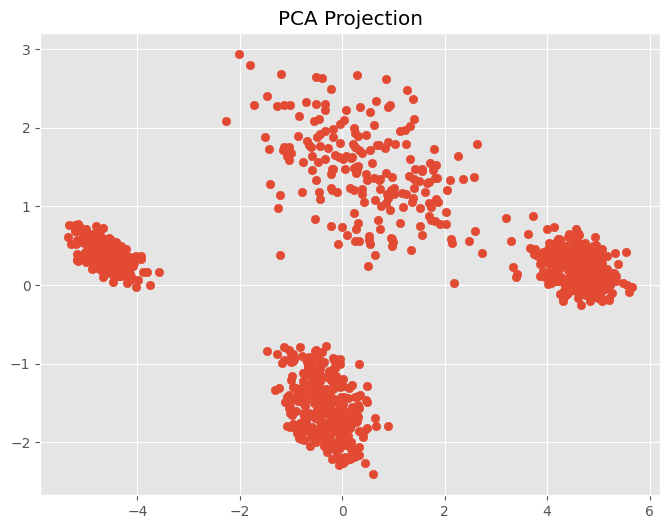

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA Projection")

plt.show()

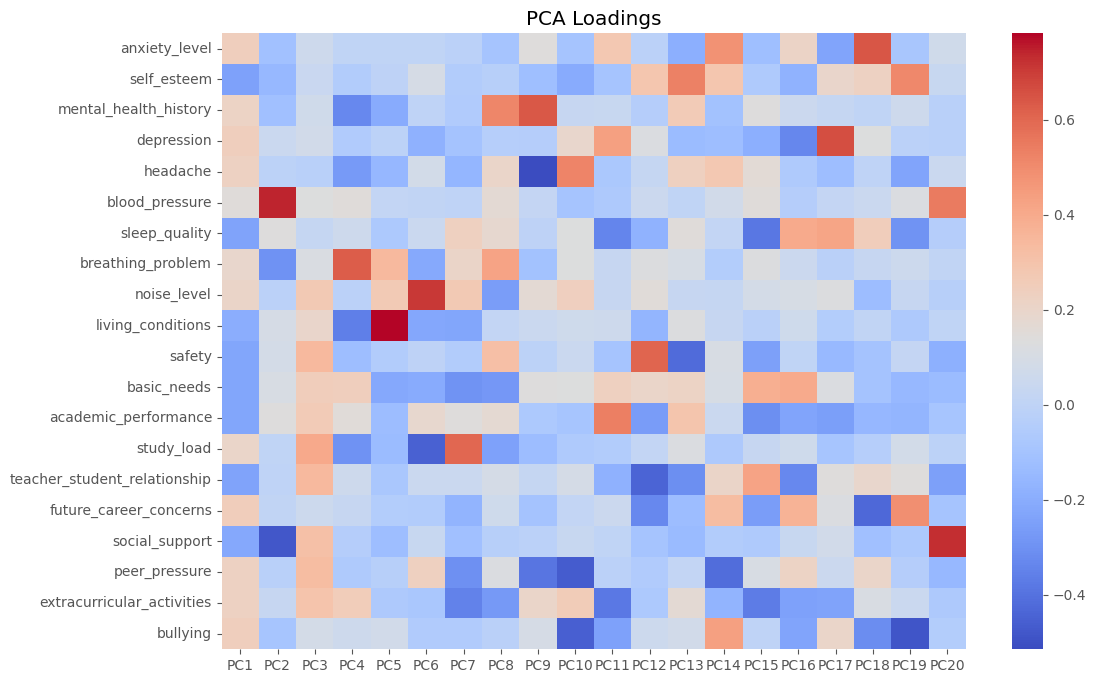

In [28]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(len(X.columns))],
    index=X.columns
)

plt.figure(figsize=(12,8))

sns.heatmap(
    loadings,
    cmap="coolwarm"
)

plt.title("PCA Loadings")

plt.show()

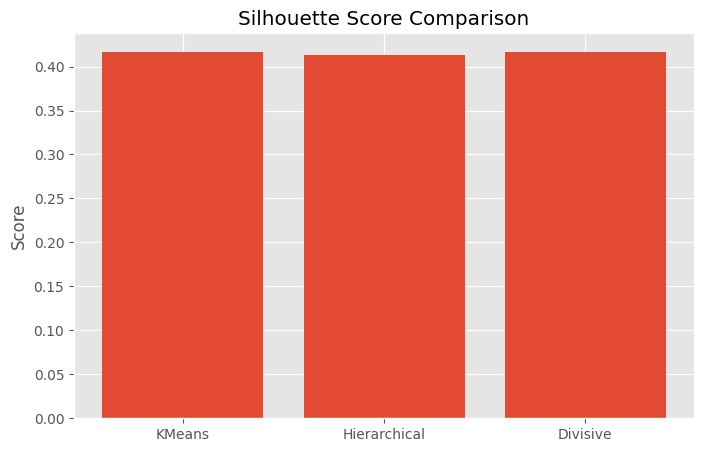

In [29]:
km_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

agg_score = silhouette_score(
    X_scaled,
    agg_labels
)

div_score = silhouette_score(
    X_scaled,
    div_labels
)

models = [
    "KMeans",
    "Hierarchical",
    "Divisive"
]

scores = [
    km_score,
    agg_score,
    div_score
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    scores
)

plt.title(
    "Silhouette Score Comparison"
)

plt.ylabel("Score")

plt.show()

In [32]:
print([x for x in globals().keys() if 'cluster' in x.lower() or 'label' in x.lower()])

['AgglomerativeClustering', 'kmeans_labels', 'agg_labels', 'div_labels', 'db_labels']


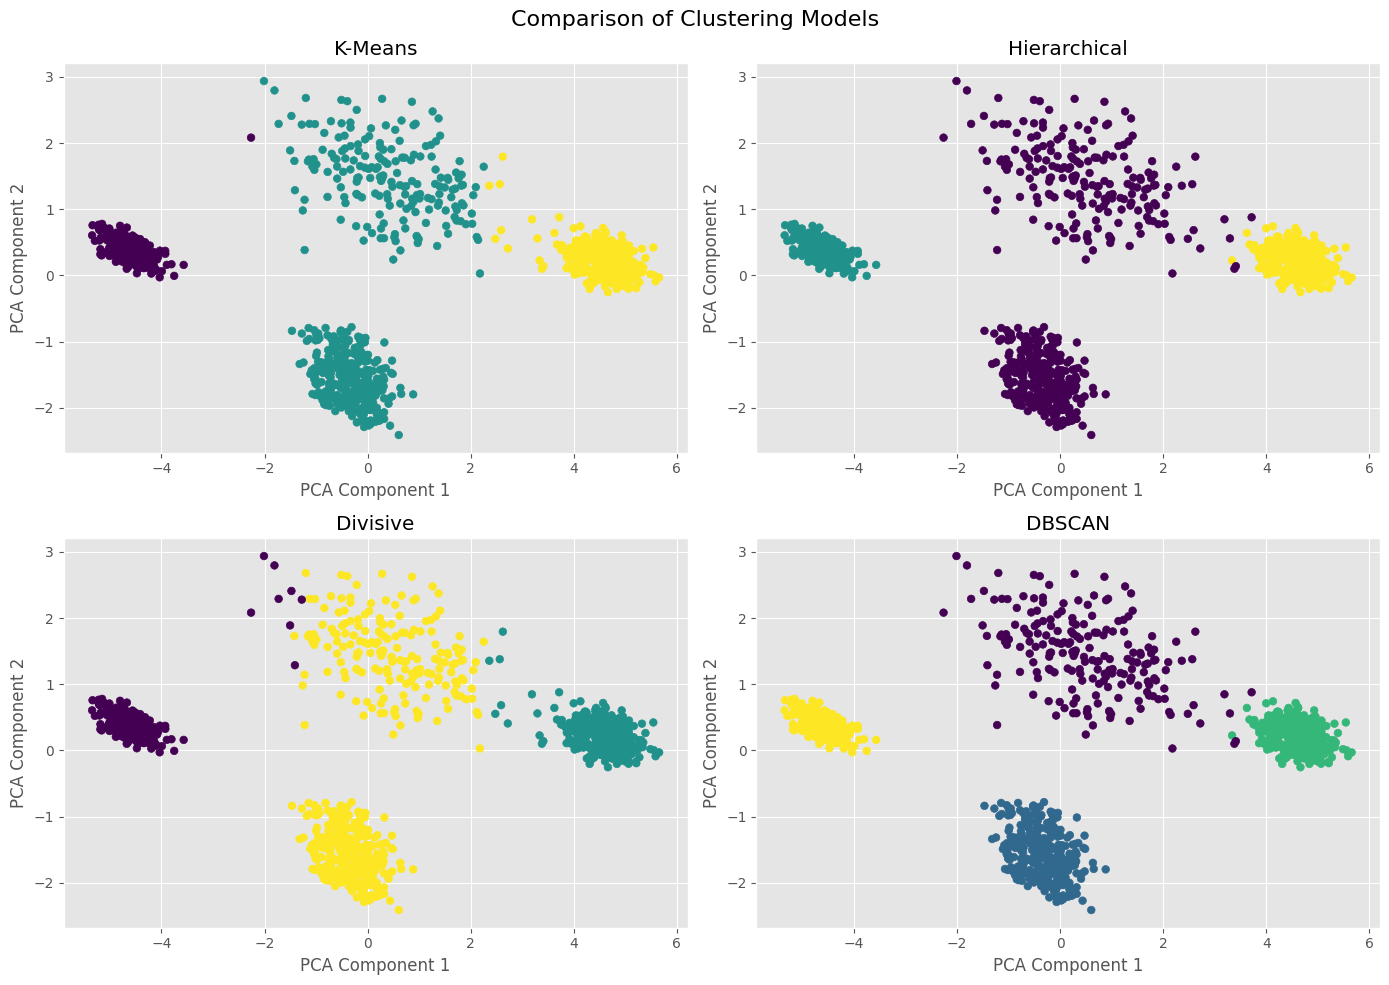

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# K-Means
axes[0,0].scatter(X_pca[:,0], X_pca[:,1],
                  c=kmeans_labels, cmap='viridis', s=30)
axes[0,0].set_title('K-Means')

# Hierarchical
axes[0,1].scatter(X_pca[:,0], X_pca[:,1],
                  c=agg_labels, cmap='viridis', s=30)
axes[0,1].set_title('Hierarchical')

# Divisive
axes[1,0].scatter(X_pca[:,0], X_pca[:,1],
                  c=div_labels, cmap='viridis', s=30)
axes[1,0].set_title('Divisive')

# DBSCAN
axes[1,1].scatter(X_pca[:,0], X_pca[:,1],
                  c=db_labels, cmap='viridis', s=30)
axes[1,1].set_title('DBSCAN')

for ax in axes.flat:
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

plt.suptitle('Comparison of Clustering Models', fontsize=16)
plt.tight_layout()
plt.show()